# Fairness Evaluation: DPD, EOD, and Predictive Performance

## What this notebook is checking

Our model looks at information available at the **25% course checkpoint** and predicts:

> **Withdrawn** versus **Others**

When the model predicts **Withdrawn**, the student is *flagged* as potentially needing support.

This notebook asks three simple questions:

1. Does the model flag some demographic groups more often than others?
2. Among students who actually withdrew, does it detect some groups better than others?
3. Can we reduce those differences without damaging the model's usefulness?

A difference between groups is a reason to investigate. It does **not**, on its own, prove discrimination or explain why the difference exists.

## 1. DPD and EOD in simple language

### DPD: Are groups flagged at different rates?

**Demographic Parity Difference (DPD)** compares the percentage of each group that the model predicts will withdraw.

Example:

- 30% of Group A is flagged.
- 20% of Group B is flagged.
- DPD = `30% - 20% = 10 percentage points`.

A DPD of `0` means equal flagging rates. A larger value means a larger difference.

**Important limitation:** DPD does **not** consider how many students actually withdrew in each group. If Group A genuinely has a higher withdrawal rate than Group B, DPD can still be large even when the predictions are accurate. Therefore, DPD cannot be used alone to declare the model fair or unfair.

DPD is useful here because it tells us whether some groups would receive many more alerts or interventions than others.

### EOD: Are actual withdrawals detected equally well?

**Equal Opportunity Difference (EOD)** looks only at students who actually withdrew. It compares the percentage correctly detected in each group.

Example:

- The model finds 80% of actual withdrawals in Group A.
- It finds 65% in Group B.
- EOD = `80% - 65% = 15 percentage points`.

An EOD of `0` means equal withdrawal-detection rates. A larger value means the model finds actual withdrawals better in some groups than in others.

EOD is especially relevant to this project: a student whom the model misses cannot receive an early intervention.

### Accuracy–fairness trade-off

A fairness intervention may reduce group differences but create more false alerts or miss more withdrawing students. We must therefore examine fairness and predictive performance together.

## 2. Other measures used in the results

| Measure | Meaning in this project |
|---|---|
| Recall / TPR | Of students who actually withdrew, how many did we correctly flag? |
| FNR | Of students who actually withdrew, how many did we miss? It is `1 - recall`. |
| FPR | Of students who did not withdraw, how many did we incorrectly flag? |
| Precision | Of all students we flagged, how many actually withdrew? |
| F1 | A single score combining precision and recall. |
| Balanced accuracy | Average performance on Withdrawn and Others. Unlike ordinary accuracy, it does not let the larger class dominate. |
| ROC-AUC / PR-AUC | How well the risk scores rank students before applying a decision threshold. |

For DPD and EOD, the notebook reports the largest eligible group rate minus the smallest. A group is used in the main comparison only when it contains at least 30 actual withdrawals and 30 non-withdrawals. Smaller groups remain visible but are not used to make strong conclusions.

In [1]:
import importlib.util
import os
import warnings
from pathlib import Path

os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
warnings.filterwarnings("ignore")

required = ["pandas", "numpy", "sklearn", "matplotlib", "seaborn", "fairlearn"]
missing = [name for name in required if importlib.util.find_spec(name) is None]
if missing:
    raise ImportError(f"Missing packages in the active environment: {missing}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fairlearn

from IPython.display import display, Markdown
from fairlearn.postprocessing import ThresholdOptimizer
from fairlearn.reductions import ErrorRate, ExponentiatedGradient, TruePositiveRateParity
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, average_precision_score, balanced_accuracy_score,
    confusion_matrix, f1_score, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

print("Fairlearn version:", fairlearn.__version__)
print("This notebook is intended for the MLDL kernel.")

Fairlearn version: 0.14.0
This notebook is intended for the MLDL kernel.


In [2]:
import warnings
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "1")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

DATA_FOLDER = "open+university+learning+analytics+dataset"
data_candidates = [
    Path(DATA_FOLDER),
    Path.cwd().parent / DATA_FOLDER,
    Path.cwd().parent.parent / DATA_FOLDER,
    Path.cwd().parent.parent.parent / DATA_FOLDER,
    Path.cwd().parent.parent.parent.parent / DATA_FOLDER,
]
DATA_DIR = next((path for path in data_candidates if path.exists()), None)
assert DATA_DIR is not None, "Dataset folder was not found in the project or its parent folders."
print("Dataset folder:", DATA_DIR.resolve())

def read_csv(name):
    return pd.read_csv(DATA_DIR / name, na_values=["?"])

assessments = read_csv("assessments.csv")
courses = read_csv("courses.csv")
student_assessment = read_csv("studentAssessment.csv")
student_info = read_csv("studentInfo.csv")
student_registration = read_csv("studentRegistration.csv")
vle = read_csv("vle.csv")

KEY = ["code_module", "code_presentation", "id_student"]
COURSE_KEY = ["code_module", "code_presentation"]

print("Loaded files:")
for name, df in {
    "assessments": assessments,
    "courses": courses,
    "student_assessment": student_assessment,
    "student_info": student_info,
    "student_registration": student_registration,
    "vle": vle,
}.items():
    print(f"{name:22s} {df.shape}")

Dataset folder: C:\Users\creak\Downloads\eMasters Capstone Project\open+university+learning+analytics+dataset


Loaded files:
assessments            (206, 6)
courses                (22, 3)
student_assessment     (173912, 5)
student_info           (32593, 12)
student_registration   (32593, 5)
vle                    (6364, 6)


## 3. Rebuild the same 25% checkpoint dataset

The following cells reuse the baseline notebook's feature engineering. Only information available by the course-relative 25% checkpoint is included. `date_unregistration` and the final result are not model inputs.

In [3]:
base = student_info.copy()
base["target_dropout"] = (base["final_result"] == "Withdrawn").astype(int)

base = base.merge(courses, on=COURSE_KEY, how="left")
base["checkpoint_day"] = np.floor(base["module_presentation_length"] * 0.25).astype(int)

print("Base shape:", base.shape)
print("\nFinal result distribution:")
display(base["final_result"].value_counts())
print("\nBinary target distribution:")
display(base["target_dropout"].value_counts().rename(index={0: "not_withdrawn", 1: "withdrawn"}))
print("\nDropout rate:", round(base["target_dropout"].mean(), 4))
base.head()

Base shape: (32593, 15)

Final result distribution:


final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64


Binary target distribution:


target_dropout
not_withdrawn    22437
withdrawn        10156
Name: count, dtype: int64


Dropout rate: 0.3116


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,disability,final_result,target_dropout,module_presentation_length,checkpoint_day
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,N,Pass,0,268,67
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,N,Pass,0,268,67
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,Y,Withdrawn,1,268,67
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,N,Pass,0,268,67
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,N,Pass,0,268,67


In [4]:
registration_features = student_registration[KEY + ["date_registration"]].copy()
registration_features["registration_missing_flag"] = (
    registration_features["date_registration"].isna().astype(int)
)

# Do not impute here. The model pipeline learns its median from the training partition only.
registration_features["registered_before_start_days"] = (
    -registration_features["date_registration"]
).clip(lower=0)
registration_features["registered_after_start_flag"] = np.where(
    registration_features["date_registration"].isna(),
    0,
    (registration_features["date_registration"] > 0).astype(int),
)

print(
    "Registration dates deliberately left missing for train-only pipeline imputation:",
    int(registration_features["date_registration"].isna().sum()),
)
registration_features.head()

Registration dates deliberately left missing for train-only pipeline imputation: 45


,code_module,code_presentation,id_student,date_registration,registration_missing_flag,registered_before_start_days,registered_after_start_flag
0,AAA,2013J,11391,-159.0,0,159.0,0
1,AAA,2013J,28400,-53.0,0,53.0,0
2,AAA,2013J,30268,-92.0,0,92.0,0
3,AAA,2013J,31604,-52.0,0,52.0,0
4,AAA,2013J,32885,-176.0,0,176.0,0


In [5]:
checkpoint_lookup = base[KEY + ["checkpoint_day"]].copy()
vle_meta = vle[["id_site", "code_module", "code_presentation", "activity_type"]].copy()

top_activity_types = (
    vle["activity_type"]
    .value_counts(dropna=False)
    .head(12)
    .index
    .tolist()
)
print("Top activity types retained:", top_activity_types)

event_parts = []
last_activity_parts = []
active_day_parts = []
distinct_site_parts = []
activity_parts = []

student_vle_path = DATA_DIR / "studentVle.csv"
usecols = ["code_module", "code_presentation", "id_student", "id_site", "date", "sum_click"]

for chunk in pd.read_csv(student_vle_path, usecols=usecols, chunksize=1_000_000):
    chunk = chunk.merge(checkpoint_lookup, on=KEY, how="inner")
    chunk = chunk[chunk["date"] <= chunk["checkpoint_day"]]
    if chunk.empty:
        continue

    event_agg = (
        chunk.groupby(KEY)
        .agg(
            total_clicks_25pct=("sum_click", "sum"),
            vle_events_25pct=("sum_click", "size"),
        )
        .reset_index()
    )
    event_parts.append(event_agg)

    last_activity_parts.append(
        chunk.groupby(KEY, as_index=False)["date"]
        .max()
        .rename(columns={"date": "last_activity_day_25pct"})
    )
    active_day_parts.append(chunk[KEY + ["date"]].drop_duplicates())
    distinct_site_parts.append(chunk[KEY + ["id_site"]].drop_duplicates())

    chunk = chunk.merge(vle_meta, on=["id_site", "code_module", "code_presentation"], how="left")
    chunk["activity_type"] = chunk["activity_type"].where(
        chunk["activity_type"].isin(top_activity_types), "other_activity"
    )
    activity_agg = (
        chunk.groupby(KEY + ["activity_type"])["sum_click"]
        .sum()
        .reset_index()
        .pivot_table(index=KEY, columns="activity_type", values="sum_click", fill_value=0)
        .reset_index()
    )
    activity_parts.append(activity_agg)

vle_events = pd.concat(event_parts, ignore_index=True).groupby(KEY, as_index=False).sum()
vle_last_activity = pd.concat(last_activity_parts, ignore_index=True).groupby(KEY, as_index=False).max()
vle_active_days = (
    pd.concat(active_day_parts, ignore_index=True)
    .drop_duplicates()
    .groupby(KEY)
    .size()
    .reset_index(name="active_days_25pct")
)
vle_distinct_sites = (
    pd.concat(distinct_site_parts, ignore_index=True)
    .drop_duplicates()
    .groupby(KEY)
    .size()
    .reset_index(name="distinct_sites_25pct")
)
vle_base = (
    vle_events
    .merge(vle_active_days, on=KEY, how="left")
    .merge(vle_distinct_sites, on=KEY, how="left")
    .merge(vle_last_activity, on=KEY, how="left")
)
vle_activity = pd.concat(activity_parts, ignore_index=True).groupby(KEY, as_index=False).sum()

vle_features = vle_base.merge(vle_activity, on=KEY, how="left")
vle_features = vle_features.merge(checkpoint_lookup, on=KEY, how="left")
vle_features["days_since_last_activity_at_checkpoint"] = (
    vle_features["checkpoint_day"] - vle_features["last_activity_day_25pct"]
)
vle_features = vle_features.drop(columns=["checkpoint_day"])

rename_map = {
    col: f"clicks_{str(col).replace('-', '_').replace(' ', '_')}_25pct"
    for col in vle_activity.columns
    if col not in KEY
}
vle_features = vle_features.rename(columns=rename_map)

print("VLE features shape:", vle_features.shape)
vle_features.head()

Top activity types retained: ['resource', 'subpage', 'oucontent', 'url', 'forumng', 'quiz', 'page', 'oucollaborate', 'questionnaire', 'ouwiki', 'dataplus', 'externalquiz']


VLE features shape: (29119, 22)


,code_module,code_presentation,id_student,total_clicks_25pct,vle_events_25pct,active_days_25pct,distinct_sites_25pct,last_activity_day_25pct,clicks_dataplus_25pct,clicks_forumng_25pct,...,clicks_oucontent_25pct,clicks_quiz_25pct,clicks_resource_25pct,clicks_subpage_25pct,clicks_url_25pct,clicks_externalquiz_25pct,clicks_ouwiki_25pct,clicks_page_25pct,clicks_questionnaire_25pct,days_since_last_activity_at_checkpoint
0,AAA,2013J,11391,545,92,19,34,65,0.0,98.0,...,344.0,0.0,9.0,23.0,1.0,0.0,0.0,0.0,0.0,2
1,AAA,2013J,28400,723,201,29,38,64,0.0,254.0,...,209.0,0.0,5.0,62.0,33.0,0.0,0.0,0.0,0.0,3
2,AAA,2013J,30268,281,76,12,22,12,0.0,126.0,...,66.0,0.0,4.0,22.0,4.0,0.0,0.0,0.0,0.0,55
3,AAA,2013J,31604,879,259,43,42,67,0.0,234.0,...,328.0,0.0,10.0,78.0,39.0,0.0,0.0,0.0,0.0,0
4,AAA,2013J,32885,608,163,29,35,67,0.0,138.0,...,315.0,0.0,7.0,29.0,6.0,0.0,0.0,0.0,0.0,0


In [6]:
assessment_defs = assessments.merge(
    courses.assign(checkpoint_day=np.floor(courses["module_presentation_length"] * 0.25).astype(int)),
    on=COURSE_KEY,
    how="left"
)
assessment_defs["date_missing_flag"] = assessment_defs["date"].isna().astype(int)
early_defs = assessment_defs[
    assessment_defs["date"].notna() & (assessment_defs["date"] <= assessment_defs["checkpoint_day"])
].copy()

early_due = (
    early_defs.groupby(COURSE_KEY)
    .agg(
        early_assessments_due_count=("id_assessment", "nunique"),
        early_assessment_weight_total=("weight", "sum"),
    )
    .reset_index()
)

early_submissions = student_assessment.merge(
    early_defs[["id_assessment", "code_module", "code_presentation", "assessment_type", "date", "weight", "checkpoint_day"]],
    on="id_assessment",
    how="inner"
)
early_submissions = early_submissions[early_submissions["date_submitted"] <= early_submissions["checkpoint_day"]].copy()
early_submissions["submission_delay"] = early_submissions["date_submitted"] - early_submissions["date"]
early_submissions["late_submission_flag"] = (early_submissions["submission_delay"] > 0).astype(int)
early_submissions["weighted_score_component"] = early_submissions["score"] * early_submissions["weight"]

assessment_features = (
    early_submissions.groupby(KEY)
    .agg(
        early_assessments_submitted_count=("id_assessment", "nunique"),
        mean_early_score=("score", "mean"),
        min_early_score=("score", "min"),
        max_early_score=("score", "max"),
        early_score_missing_count=("score", lambda s: s.isna().sum()),
        weighted_early_score_num=("weighted_score_component", "sum"),
        submitted_early_weight_total=("weight", "sum"),
        average_submission_delay=("submission_delay", "mean"),
        late_submission_count=("late_submission_flag", "sum"),
        banked_assessment_count=("is_banked", "sum"),
    )
    .reset_index()
)
assessment_features["weighted_early_score"] = np.where(
    assessment_features["submitted_early_weight_total"] > 0,
    assessment_features["weighted_early_score_num"] / assessment_features["submitted_early_weight_total"],
    np.nan,
)
assessment_features = assessment_features.drop(columns=["weighted_early_score_num"])

assessment_features = assessment_features.merge(base[KEY].drop_duplicates(), on=KEY, how="right")
assessment_features = assessment_features.merge(early_due, on=COURSE_KEY, how="left")
assessment_features["early_assessments_due_count"] = assessment_features["early_assessments_due_count"].fillna(0)
assessment_features["early_assessment_weight_total"] = assessment_features["early_assessment_weight_total"].fillna(0)
assessment_features["early_assessments_submitted_count"] = assessment_features["early_assessments_submitted_count"].fillna(0)
assessment_features["early_assessments_missing_count"] = (
    assessment_features["early_assessments_due_count"] - assessment_features["early_assessments_submitted_count"]
).clip(lower=0)

print("Assessment features shape:", assessment_features.shape)
assessment_features.head()

Assessment features shape: (32593, 16)


,code_module,code_presentation,id_student,early_assessments_submitted_count,mean_early_score,min_early_score,max_early_score,early_score_missing_count,submitted_early_weight_total,average_submission_delay,late_submission_count,banked_assessment_count,weighted_early_score,early_assessments_due_count,early_assessment_weight_total,early_assessments_missing_count
0,AAA,2013J,11391,2.0,81.5,78.0,85.0,0.0,30.0,-1.0,0.0,0.0,82.666667,2.0,30.0,0.0
1,AAA,2013J,28400,2.0,69.0,68.0,70.0,0.0,30.0,0.5,1.0,0.0,68.666667,2.0,30.0,0.0
2,AAA,2013J,30268,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,30.0,2.0
3,AAA,2013J,31604,2.0,71.5,71.0,72.0,0.0,30.0,-2.5,0.0,0.0,71.333333,2.0,30.0,0.0
4,AAA,2013J,32885,1.0,69.0,69.0,69.0,0.0,10.0,7.0,1.0,0.0,69.000000,2.0,30.0,1.0


In [7]:
profile_cols = [
    "code_module", "code_presentation", "id_student",
    "gender", "region", "highest_education", "imd_band", "age_band",
    "num_of_prev_attempts", "studied_credits", "disability",
    "module_presentation_length", "checkpoint_day", "target_dropout"
]

final_modeling_dataset = base[profile_cols].copy()
final_modeling_dataset["imd_band"] = final_modeling_dataset["imd_band"].fillna("Unknown")

final_modeling_dataset = final_modeling_dataset.merge(registration_features, on=KEY, how="left")
final_modeling_dataset = final_modeling_dataset.merge(vle_features, on=KEY, how="left")
final_modeling_dataset = final_modeling_dataset.merge(assessment_features, on=KEY, how="left")

# Preserve the difference between no VLE activity and activity on the checkpoint day.
final_modeling_dataset["no_early_vle_activity_flag"] = (
    final_modeling_dataset["last_activity_day_25pct"].isna().astype(int)
)

# Missing count values after a left join mean that no such early event was recorded.
# Recency and score values are intentionally NOT filled here; the training-only pipeline
# will learn their imputation values.
zero_fill_prefixes = [
    "total_clicks", "vle_events", "active_days", "distinct_sites",
    "clicks_", "early_assessments", "late_submission", "banked_assessment",
    "early_score_missing", "early_assessment_weight", "submitted_early_weight"
]
for col in final_modeling_dataset.columns:
    if any(col.startswith(prefix) for prefix in zero_fill_prefixes):
        final_modeling_dataset[col] = final_modeling_dataset[col].fillna(0)

score_or_timing_features = [
    "mean_early_score", "min_early_score", "max_early_score",
    "weighted_early_score", "average_submission_delay"
]
for col in score_or_timing_features:
    if col in final_modeling_dataset.columns:
        final_modeling_dataset[f"{col}_missing_flag"] = (
            final_modeling_dataset[col].isna().astype(int)
        )

print("Final modeling dataset shape:", final_modeling_dataset.shape)
print("Duplicate modeling keys:", final_modeling_dataset.duplicated(KEY).sum())
print("\nTarget distribution:")
display(final_modeling_dataset["target_dropout"].value_counts())
print("\nMissing values retained for train-only imputation:")
display(final_modeling_dataset.isna().sum().sort_values(ascending=False).head(20))
final_modeling_dataset.head()

Final modeling dataset shape: (32593, 56)
Duplicate modeling keys: 0

Target distribution:


target_dropout
0    22437
1    10156
Name: count, dtype: int64


Missing values retained for train-only imputation:


weighted_early_score                      9234
mean_early_score                          7727
min_early_score                           7727
max_early_score                           7727
average_submission_delay                  7706
days_since_last_activity_at_checkpoint    3474
last_activity_day_25pct                   3474
date_registration                           45
registered_before_start_days                45
clicks_externalquiz_25pct                    0
clicks_ouwiki_25pct                          0
clicks_page_25pct                            0
clicks_questionnaire_25pct                   0
early_assessments_submitted_count            0
early_score_missing_count                    0
code_module                                  0
submitted_early_weight_total                 0
clicks_subpage_25pct                         0
late_submission_count                        0
banked_assessment_count                      0
dtype: int64

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,weighted_early_score,early_assessments_due_count,early_assessment_weight_total,early_assessments_missing_count,no_early_vle_activity_flag,mean_early_score_missing_flag,min_early_score_missing_flag,max_early_score_missing_flag,weighted_early_score_missing_flag,average_submission_delay_missing_flag
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,82.666667,2.0,30.0,0.0,0,0,0,0,0,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,68.666667,2.0,30.0,0.0,0,0,0,0,0,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,NaN,2.0,30.0,2.0,0,1,1,1,1,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,71.333333,2.0,30.0,0.0,0,0,0,0,0,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,69.000000,2.0,30.0,1.0,0,0,0,0,0,0


In [8]:
numeric_features = final_modeling_dataset.select_dtypes(include=[np.number]).columns.tolist()
numeric_features = [c for c in numeric_features if c not in ["id_student", "target_dropout"]]

categorical_features = [
    c for c in final_modeling_dataset.select_dtypes(include=["object"]).columns
    if c not in []
]

excluded_from_model = [
    "id_student",          # identifier only
    "target_dropout",     # target
    "final_result",        # original target; not in final dataset
    "date_unregistration", # leakage; not in final dataset
]

print("Numeric feature count:", len(numeric_features))
print("Categorical feature count:", len(categorical_features))
print("\nNumeric features:")
print(numeric_features)
print("\nCategorical features:")
print(categorical_features)
print("\nExplicitly excluded:")
print(excluded_from_model)

Numeric feature count: 46
Categorical feature count: 8

Numeric features:
['num_of_prev_attempts', 'studied_credits', 'module_presentation_length', 'checkpoint_day', 'date_registration', 'registration_missing_flag', 'registered_before_start_days', 'registered_after_start_flag', 'total_clicks_25pct', 'vle_events_25pct', 'active_days_25pct', 'distinct_sites_25pct', 'last_activity_day_25pct', 'clicks_dataplus_25pct', 'clicks_forumng_25pct', 'clicks_other_activity_25pct', 'clicks_oucollaborate_25pct', 'clicks_oucontent_25pct', 'clicks_quiz_25pct', 'clicks_resource_25pct', 'clicks_subpage_25pct', 'clicks_url_25pct', 'clicks_externalquiz_25pct', 'clicks_ouwiki_25pct', 'clicks_page_25pct', 'clicks_questionnaire_25pct', 'days_since_last_activity_at_checkpoint', 'early_assessments_submitted_count', 'mean_early_score', 'min_early_score', 'max_early_score', 'early_score_missing_count', 'submitted_early_weight_total', 'average_submission_delay', 'late_submission_count', 'banked_assessment_count', 

## 4. Recreate the same student-safe partitions

All enrollments belonging to one student remain in one partition. This prevents the same learner from appearing in both training and evaluation/test data.

In [9]:
X = final_modeling_dataset[numeric_features + categorical_features].copy()
y = final_modeling_dataset["target_dropout"].copy()
student_groups = final_modeling_dataset["id_student"].copy()

splitter = StratifiedGroupKFold(n_splits=20, shuffle=True, random_state=42)
fold_assignment = np.full(len(X), -1, dtype=int)
for fold_number, (_, fold_indices) in enumerate(splitter.split(X, y, groups=student_groups)):
    fold_assignment[fold_indices] = fold_number

test_mask = np.isin(fold_assignment, [0, 1, 2])
eval_mask = np.isin(fold_assignment, [3, 4, 5])
train_mask = ~(test_mask | eval_mask)

X_train, y_train = X.loc[train_mask].copy(), y.loc[train_mask].copy()
X_eval, y_eval = X.loc[eval_mask].copy(), y.loc[eval_mask].copy()
X_test, y_test = X.loc[test_mask].copy(), y.loc[test_mask].copy()
groups_train = student_groups.loc[train_mask].copy()
groups_eval = student_groups.loc[eval_mask].copy()
groups_test = student_groups.loc[test_mask].copy()

assert set(groups_train).isdisjoint(set(groups_eval))
assert set(groups_train).isdisjoint(set(groups_test))
assert set(groups_eval).isdisjoint(set(groups_test))

split_audit = pd.DataFrame([
    {
        "partition": name,
        "rows": len(target),
        "students": groups.nunique(),
        "withdrawals": int(target.sum()),
        "withdrawal_rate": float(target.mean()),
    }
    for name, target, groups in [
        ("Training", y_train, groups_train),
        ("Evaluation", y_eval, groups_eval),
        ("Held-out test", y_test, groups_test),
    ]
])
display(split_audit.style.format({"withdrawal_rate": "{:.1%}"}))

,partition,rows,students,withdrawals,withdrawal_rate
0,Training,22833,20138,7141,31.3%
1,Evaluation,4864,4317,1540,31.7%
2,Held-out test,4896,4330,1475,30.1%


## 5. What models are being compared?

### 1. Current HGB

Our existing weighted HistGradientBoosting model. It uses the same features and withdrawal weight of `3.0` as the baseline notebook.

### 2. Protected predictors removed

The same HGB model, but gender, disability, IMD, age and education are removed from the prediction inputs. We retain these columns only to check the model afterward.

Removing these columns does not guarantee equal results. Other features can still be related to demographic circumstances, and actual withdrawal rates can differ between groups.

### 3. Intersectionally reweighted HGB

The model still applies one common rule to everyone. During training, less common gender × disability × deprivation outcome groups receive more weight so that they are not overlooked.

### 4. Equal-opportunity-constrained HGB

Fairlearn repeatedly trains HGB models while paying additional attention to groups with lower withdrawal recall. Its goal is to make recall more similar across gender × disability × deprivation groups.

Protected attributes are used to measure the training constraint, but they are not prediction inputs and are not required when this model makes a prediction.

### 5. Group-specific threshold benchmark

This method can use a different decision threshold for each demographic group. It shows what fairness numbers might be achievable with group-aware decisions, but it is **not eligible for selection** because it applies different decision rules using protected information at prediction time.

In [10]:
def add_audit_groups(frame):
    out = pd.DataFrame(index=frame.index)
    out["gender"] = frame["gender"].fillna("Unknown").astype(str)
    out["disability"] = frame["disability"].fillna("Unknown").astype(str)
    out["imd_band"] = frame["imd_band"].fillna("Unknown").astype(str)
    deprived_bands = {"0-10%", "10-20", "20-30%", "10-20%"}
    out["deprivation_group"] = np.where(
        out["imd_band"].eq("Unknown"), "Unknown IMD",
        np.where(out["imd_band"].isin(deprived_bands), "Lowest 30% IMD", "Other known IMD")
    )
    out["gender_x_disability"] = out["gender"] + " | disability=" + out["disability"]
    out["disability_x_deprivation"] = out["disability"] + " | " + out["deprivation_group"]
    out["age_band"] = frame["age_band"].fillna("Unknown").astype(str)
    out["highest_education"] = frame["highest_education"].fillna("Unknown").astype(str)
    return out.reset_index(drop=True)

audit_train = add_audit_groups(X_train)
audit_eval = add_audit_groups(X_eval)
audit_test = add_audit_groups(X_test)

primary_attributes = [
    "gender", "disability", "imd_band",
    "gender_x_disability", "disability_x_deprivation",
]
secondary_attributes = ["age_band", "highest_education"]
all_audit_attributes = primary_attributes + secondary_attributes

intersection_train = (
    audit_train["gender_x_disability"] + " | " + audit_train["deprivation_group"]
)
intersection_eval = (
    audit_eval["gender_x_disability"] + " | " + audit_eval["deprivation_group"]
)
intersection_test = (
    audit_test["gender_x_disability"] + " | " + audit_test["deprivation_group"]
)

protected_predictors = ["gender", "disability", "imd_band", "age_band", "highest_education"]
unaware_numeric = [c for c in numeric_features if c not in protected_predictors]
unaware_categorical = [c for c in categorical_features if c not in protected_predictors]
unaware_features = unaware_numeric + unaware_categorical

def make_preprocessor(num_cols, cat_cols):
    try:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        encoder = OneHotEncoder(handle_unknown="ignore", sparse=False)
    return ColumnTransformer([
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", encoder),
        ]), cat_cols),
    ])

def make_hgb(num_cols=numeric_features, cat_cols=categorical_features):
    return Pipeline([
        ("preprocess", make_preprocessor(num_cols, cat_cols)),
        ("model", HistGradientBoostingClassifier(
            loss="log_loss", learning_rate=0.08, max_iter=200, random_state=42,
        )),
    ])

def withdrawal_weights(target, positive_weight=3.0):
    weights = np.where(np.asarray(target) == 1, positive_weight, 1.0).astype(float)
    return weights / weights.mean()

def intersectional_weights(target, sensitive, positive_weight=3.0):
    temp = pd.DataFrame({"y": np.asarray(target), "group": np.asarray(sensitive)})
    cell_counts = temp.groupby(["y", "group"])["y"].transform("size")
    class_counts = temp.groupby("y")["y"].transform("size")
    distinct_groups = temp.groupby("y")["group"].transform("nunique")
    group_factor = class_counts / (cell_counts * distinct_groups)
    group_factor = group_factor.clip(0.25, 4.0)
    weights = group_factor.to_numpy() * np.where(temp["y"].to_numpy() == 1, positive_weight, 1.0)
    return weights / weights.mean()

## 6. How the group comparisons are calculated

The first table reports what happened inside each demographic group. The gap table then compares the highest and lowest eligible group values.

The confidence intervals later in the notebook repeatedly resample complete students. This helps show whether an observed DPD or EOD value is reasonably stable or could move substantially with a different sample.

In [11]:
def predictive_metrics(name, actual, prediction, probability=None):
    actual = np.asarray(actual).astype(int)
    prediction = np.asarray(prediction).astype(int)
    tn, fp, fn, tp = confusion_matrix(actual, prediction, labels=[0, 1]).ravel()
    row = {
        "model": name,
        "accuracy": accuracy_score(actual, prediction),
        "balanced_accuracy": balanced_accuracy_score(actual, prediction),
        "precision": precision_score(actual, prediction, zero_division=0),
        "recall": recall_score(actual, prediction, zero_division=0),
        "f1": f1_score(actual, prediction, zero_division=0),
        "fp": int(fp), "fn": int(fn),
    }
    if probability is not None:
        row["roc_auc"] = roc_auc_score(actual, probability)
        row["pr_auc"] = average_precision_score(actual, probability)
    else:
        row["roc_auc"] = np.nan
        row["pr_auc"] = np.nan
    return row

def group_fairness_table(actual, prediction, audit_frame, attributes, model_name):
    actual = np.asarray(actual).astype(int)
    prediction = np.asarray(prediction).astype(int)
    rows = []
    for attribute in attributes:
        values = audit_frame[attribute].fillna("Unknown").astype(str).to_numpy()
        for group in sorted(pd.unique(values)):
            mask = values == group
            tn, fp, fn, tp = confusion_matrix(actual[mask], prediction[mask], labels=[0, 1]).ravel()
            positives, negatives, flagged = tp + fn, tn + fp, tp + fp
            eligible = positives >= 30 and negatives >= 30
            # Missing IMD stays visible in the detailed table, but it is not a
            # deprivation category and must not define the primary DPD/EOD gap.
            if attribute == "imd_band" and group == "Unknown":
                eligible = False
            if attribute == "disability_x_deprivation" and "Unknown IMD" in group:
                eligible = False
            rows.append({
                "model": model_name, "attribute": attribute, "group": group,
                "n": int(mask.sum()), "actual_withdrawn": int(positives),
                "actual_not_withdrawn": int(negatives),
                "withdrawal_rate": positives / mask.sum(),
                "selection_rate": flagged / mask.sum(),
                "tpr_recall": tp / positives if positives else np.nan,
                "fnr": fn / positives if positives else np.nan,
                "fpr": fp / negatives if negatives else np.nan,
                "precision": tp / flagged if flagged else np.nan,
                "accuracy": (tp + tn) / mask.sum(),
                "eligible": eligible,
            })
    return pd.DataFrame(rows)

def fairness_gap_table(group_table):
    rows = []
    for (model, attribute), part in group_table.groupby(["model", "attribute"], sort=False):
        eligible = part[part["eligible"]]
        selection = eligible["selection_rate"].dropna()
        tpr = eligible["tpr_recall"].dropna()
        rows.append({
            "model": model,
            "attribute": attribute,
            "eligible_groups": len(eligible),
            "dpd": selection.max() - selection.min() if len(selection) >= 2 else np.nan,
            "dp_ratio": selection.min() / selection.max() if len(selection) >= 2 and selection.max() > 0 else np.nan,
            "eod": tpr.max() - tpr.min() if len(tpr) >= 2 else np.nan,
            "lowest_selection_group": eligible.loc[eligible["selection_rate"].idxmin(), "group"] if len(selection) else None,
            "highest_selection_group": eligible.loc[eligible["selection_rate"].idxmax(), "group"] if len(selection) else None,
            "lowest_recall_group": eligible.loc[eligible["tpr_recall"].idxmin(), "group"] if len(tpr) else None,
            "highest_recall_group": eligible.loc[eligible["tpr_recall"].idxmax(), "group"] if len(tpr) else None,
        })
    return pd.DataFrame(rows)

def worst_primary_gaps(gap_table, model_name):
    part = gap_table[(gap_table["model"] == model_name) & gap_table["attribute"].isin(primary_attributes)]
    return float(part["dpd"].max()), float(part["eod"].max())

## 7. Choosing the fairness-constraint strength

The Fairlearn model needs a tolerance called `epsilon`. A smaller epsilon generally asks for a stricter training constraint, but it does not guarantee the same EOD on unseen data.

The notebook tests `0.02`, `0.05`, and `0.10` using three student-grouped folds inside the training data. Evaluation and test students are not used to choose this setting.

In [12]:
fairness_epsilons = [0.02, 0.05, 0.10]
fairness_cv = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=42)
fairness_cv_rows = []

for fold, (fit_idx, valid_idx) in enumerate(
    fairness_cv.split(X_train[unaware_features], y_train, groups=groups_train), start=1
):
    fold_X_fit = X_train.iloc[fit_idx][unaware_features]
    fold_y_fit = y_train.iloc[fit_idx]
    fold_X_valid = X_train.iloc[valid_idx][unaware_features]
    fold_y_valid = y_train.iloc[valid_idx]
    fold_sensitive_fit = intersection_train.iloc[fit_idx]
    fold_sensitive_valid = intersection_train.iloc[valid_idx]
    fold_audit = audit_train.iloc[valid_idx].reset_index(drop=True)

    for epsilon in fairness_epsilons:
        mitigator = ExponentiatedGradient(
            estimator=make_hgb(unaware_numeric, unaware_categorical),
            constraints=TruePositiveRateParity(difference_bound=epsilon),
            objective=ErrorRate(), eps=0.02, max_iter=12,
            sample_weight_name="model__sample_weight",
        )
        mitigator.fit(fold_X_fit, fold_y_fit, sensitive_features=fold_sensitive_fit)
        pred = mitigator.predict(fold_X_valid, random_state=42).astype(int)
        model_name = f"Fair HGB eps={epsilon:.2f}"
        metrics = predictive_metrics(model_name, fold_y_valid, pred)
        group_table = group_fairness_table(
            fold_y_valid, pred, fold_audit, primary_attributes, model_name
        )
        gaps = fairness_gap_table(group_table)
        fairness_cv_rows.append({
            "fold": fold, "epsilon": epsilon,
            "f1": metrics["f1"], "balanced_accuracy": metrics["balanced_accuracy"],
            "worst_dpd": gaps["dpd"].max(), "worst_eod": gaps["eod"].max(),
        })

fairness_cv_results = pd.DataFrame(fairness_cv_rows)
fairness_cv_summary = fairness_cv_results.groupby("epsilon").agg(
    f1_mean=("f1", "mean"),
    balanced_accuracy_mean=("balanced_accuracy", "mean"),
    worst_dpd_mean=("worst_dpd", "mean"),
    worst_eod_mean=("worst_eod", "mean"),
).reset_index()

selected_epsilon = float(fairness_cv_summary.sort_values(
    ["worst_eod_mean", "f1_mean", "balanced_accuracy_mean"],
    ascending=[True, False, False],
).iloc[0]["epsilon"])

display(fairness_cv_summary.style.format({
    "epsilon": "{:.2f}", "f1_mean": "{:.3f}",
    "balanced_accuracy_mean": "{:.3f}", "worst_dpd_mean": "{:.3f}",
    "worst_eod_mean": "{:.3f}",
}))
print("Training-only selected Fairlearn tolerance:", selected_epsilon)

,epsilon,f1_mean,balanced_accuracy_mean,worst_dpd_mean,worst_eod_mean
0,0.02,0.711,0.784,0.136,0.106
1,0.05,0.717,0.788,0.138,0.121
2,0.10,0.717,0.788,0.136,0.102


Training-only selected Fairlearn tolerance: 0.1


## 8. Main comparison on the evaluation partition

This table compares predictive performance and fairness on students who were not used to train the models.

Except for the explicitly labelled group-specific benchmark, every candidate uses one common decision threshold of `0.50` for all students.

In [13]:
evaluation_predictions = {}
evaluation_probabilities = {}
fitted_candidates = {}

# 1. Current selected HGB
baseline_model = make_hgb()
baseline_model.fit(X_train, y_train, model__sample_weight=withdrawal_weights(y_train))
baseline_prob = baseline_model.predict_proba(X_eval)[:, 1]
evaluation_probabilities["Current HGB"] = baseline_prob
evaluation_predictions["Current HGB"] = (baseline_prob >= 0.50).astype(int)
fitted_candidates["Current HGB"] = baseline_model

# 2. Protected predictors removed
unaware_model = make_hgb(unaware_numeric, unaware_categorical)
unaware_model.fit(
    X_train[unaware_features], y_train,
    model__sample_weight=withdrawal_weights(y_train),
)
unaware_prob = unaware_model.predict_proba(X_eval[unaware_features])[:, 1]
evaluation_probabilities["Protected predictors removed"] = unaware_prob
evaluation_predictions["Protected predictors removed"] = (unaware_prob >= 0.50).astype(int)
fitted_candidates["Protected predictors removed"] = unaware_model

# 3. Intersectional reweighting
reweighted_model = make_hgb()
reweighted_model.fit(
    X_train, y_train,
    model__sample_weight=intersectional_weights(y_train, intersection_train),
)
reweighted_prob = reweighted_model.predict_proba(X_eval)[:, 1]
evaluation_probabilities["Intersectionally reweighted HGB"] = reweighted_prob
evaluation_predictions["Intersectionally reweighted HGB"] = (reweighted_prob >= 0.50).astype(int)
fitted_candidates["Intersectionally reweighted HGB"] = reweighted_model

# 4. Fairlearn-constrained HGB
fair_model = ExponentiatedGradient(
    estimator=make_hgb(unaware_numeric, unaware_categorical),
    constraints=TruePositiveRateParity(difference_bound=selected_epsilon),
    objective=ErrorRate(), eps=0.02, max_iter=12,
    sample_weight_name="model__sample_weight",
)
fair_model.fit(
    X_train[unaware_features], y_train,
    sensitive_features=intersection_train,
)
fair_pred = fair_model.predict(X_eval[unaware_features], random_state=42).astype(int)
fair_name = f"Equal-opportunity-constrained HGB (eps={selected_epsilon:.2f})"
evaluation_predictions[fair_name] = fair_pred
fitted_candidates[fair_name] = fair_model

# 5. Group-specific threshold benchmark (not eligible for selection)
threshold_model = ThresholdOptimizer(
    estimator=baseline_model,
    constraints="true_positive_rate_parity",
    objective="balanced_accuracy_score",
    prefit=True,
    predict_method="predict_proba",
    grid_size=200,
)
threshold_model.fit(X_train, y_train, sensitive_features=intersection_train)
threshold_pred = threshold_model.predict(
    X_eval, sensitive_features=intersection_eval, random_state=42
).astype(int)
threshold_name = "Group-specific thresholds (benchmark only)"
evaluation_predictions[threshold_name] = threshold_pred

metric_rows = []
group_tables = []
for name, pred in evaluation_predictions.items():
    metric_rows.append(predictive_metrics(
        name, y_eval, pred, evaluation_probabilities.get(name)
    ))
    group_tables.append(group_fairness_table(
        y_eval.reset_index(drop=True), pred, audit_eval,
        all_audit_attributes, name,
    ))

model_metrics = pd.DataFrame(metric_rows)
all_group_results = pd.concat(group_tables, ignore_index=True)
gap_results = fairness_gap_table(all_group_results)

worst_rows = []
for name in evaluation_predictions:
    dpd, eod = worst_primary_gaps(gap_results, name)
    worst_rows.append({"model": name, "worst_primary_dpd": dpd, "worst_primary_eod": eod})
worst_gaps = pd.DataFrame(worst_rows)
evaluation_comparison = model_metrics.merge(worst_gaps, on="model")

display(evaluation_comparison.style.format({
    "accuracy": "{:.3f}", "balanced_accuracy": "{:.3f}",
    "roc_auc": lambda x: "—" if pd.isna(x) else f"{x:.3f}",
    "pr_auc": lambda x: "—" if pd.isna(x) else f"{x:.3f}",
    "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}",
    "worst_primary_dpd": "{:.3f}", "worst_primary_eod": "{:.3f}",
}))

,model,accuracy,balanced_accuracy,precision,recall,f1,fp,fn,roc_auc,pr_auc,worst_primary_dpd,worst_primary_eod
0,Current HGB,0.825,0.819,0.693,0.803,0.744,548,303,0.884,0.825,0.214,0.106
1,Protected predictors removed,0.822,0.816,0.688,0.800,0.740,559,308,0.884,0.824,0.180,0.090
2,Intersectionally reweighted HGB,0.821,0.812,0.690,0.788,0.736,546,326,0.878,0.810,0.186,0.102
3,Equal-opportunity-constrained HGB (eps=0.10),0.837,0.788,0.797,0.653,0.718,257,534,—,—,0.173,0.152
4,Group-specific thresholds (benchmark only),0.825,0.818,0.693,0.800,0.743,545,308,—,—,0.143,0.067


### Findings from the main comparison

#### Original HGB

- Worst DPD: `0.214`, meaning the most separated eligible groups differed by **21.4 percentage points** in how often they were flagged.
- Worst EOD: `0.106`, meaning withdrawal recall differed by up to **10.6 percentage points**.
- Gender alone had only small differences. Larger gaps appeared for disability, deprivation and their intersections.
- DPD does not tell us whether these differences are justified, because actual withdrawal rates also differ between groups.

#### Protected predictors removed

- DPD improved from `0.214` to `0.180`.
- EOD improved from `0.106` to `0.090`.
- F1 changed only from `0.744` to `0.740`.

This was a useful group-blind improvement with very little predictive cost.

#### Fairness-constrained HGB

- DPD improved to `0.173`, but EOD became worse at `0.152`.
- Recall fell from `0.803` to `0.653`.
- Missed withdrawals increased from `303` to `534`.
- Ordinary accuracy increased because the model made fewer withdrawal predictions, but balanced accuracy and F1 decreased.

The constraint therefore did not produce a useful result on evaluation data.

#### Group-specific threshold benchmark

- DPD improved to `0.143` and EOD to `0.067` with almost unchanged F1.
- This was the strongest numerical fairness result, but it uses protected group information to apply different decision rules. It remains a benchmark rather than the recommended model.

### How to read the comparison

- Lower DPD means the groups are flagged at more similar rates.
- Lower EOD means actual withdrawals are detected more equally across groups.
- Higher F1 and balanced accuracy mean better overall classification.
- A fairness value is not useful if it improves only because the model becomes poor for everybody.
- ROC-AUC and PR-AUC are blank for Fairlearn's randomized decision rules because those methods return final decisions rather than one directly comparable risk score.

In [14]:
baseline_row = evaluation_comparison.set_index("model").loc["Current HGB"]
selectable_names = [
    "Current HGB",
    "Protected predictors removed",
    "Intersectionally reweighted HGB",
    fair_name,
]
selection_table = evaluation_comparison[
    evaluation_comparison["model"].isin(selectable_names)
].copy()
selection_table["f1_loss_vs_baseline"] = baseline_row["f1"] - selection_table["f1"]
selection_table["dpd_change_vs_baseline"] = (
    selection_table["worst_primary_dpd"] - baseline_row["worst_primary_dpd"]
)
selection_table["eligible"] = (
    (selection_table["f1_loss_vs_baseline"] <= 0.02 + 1e-12)
    & (selection_table["dpd_change_vs_baseline"] <= 0.02 + 1e-12)
)

eligible = selection_table[selection_table["eligible"]].copy()
selected_row = eligible.sort_values(
    ["worst_primary_eod", "f1", "balanced_accuracy"],
    ascending=[True, False, False],
).iloc[0]
selected_model_name = selected_row["model"]
selected_threshold = 0.50

display(selection_table[[
    "model", "f1", "balanced_accuracy", "worst_primary_dpd",
    "worst_primary_eod", "f1_loss_vs_baseline", "dpd_change_vs_baseline", "eligible",
]].style.format({
    "f1": "{:.3f}", "balanced_accuracy": "{:.3f}",
    "worst_primary_dpd": "{:.3f}", "worst_primary_eod": "{:.3f}",
    "f1_loss_vs_baseline": "{:+.3f}", "dpd_change_vs_baseline": "{:+.3f}",
}))
print("Selected group-blind candidate:", selected_model_name)
print("Frozen common threshold:", selected_threshold)

,model,f1,balanced_accuracy,worst_primary_dpd,worst_primary_eod,f1_loss_vs_baseline,dpd_change_vs_baseline,eligible
0,Current HGB,0.744,0.819,0.214,0.106,+0.000,+0.000,True
1,Protected predictors removed,0.740,0.816,0.180,0.090,+0.004,-0.034,True
2,Intersectionally reweighted HGB,0.736,0.812,0.186,0.102,+0.008,-0.029,True
3,Equal-opportunity-constrained HGB (eps=0.10),0.718,0.788,0.173,0.152,+0.026,-0.042,False


Selected group-blind candidate: Protected predictors removed
Frozen common threshold: 0.5


### Why the protected-feature-removed model was selected

The selection rule prioritised lower EOD, allowed at most `0.02` F1 loss, and did not allow DPD to worsen by more than `0.02`.

- Protected-feature removal met the guardrails and had the lowest EOD among eligible group-blind candidates.
- Intersectional reweighting remained eligible but produced smaller fairness improvements.
- The constrained model lost `0.026` F1 and made EOD worse, so it was ineligible.

Removing protected predictors is therefore the best practical candidate from this evaluation—not proof that every fairness concern has been solved.

## 9. Which groups produced the differences?

The first table shows the original HGB result for each primary demographic group.

- `selection_rate` is the percentage flagged by the model and is used for DPD.
- `tpr_recall` is the percentage of actual withdrawals detected and is used for EOD.
- `eligible = False` means the group is too small for a stable main comparison.

The second table directly compares DPD and EOD for the original and selected models.

In [15]:
display(
    all_group_results[
        (all_group_results["model"] == "Current HGB")
        & all_group_results["attribute"].isin(primary_attributes)
    ].style.format({
        "withdrawal_rate": "{:.1%}", "selection_rate": "{:.1%}",
        "tpr_recall": "{:.1%}", "fnr": "{:.1%}", "fpr": "{:.1%}",
        "precision": "{:.1%}", "accuracy": "{:.1%}",
    })
)

print("Gap summary for current and selected models:")
display(
    gap_results[
        gap_results["model"].isin({"Current HGB", selected_model_name})
        & gap_results["attribute"].isin(all_audit_attributes)
    ].style.format({"dpd": "{:.3f}", "dp_ratio": "{:.3f}", "eod": "{:.3f}"})
)

,model,attribute,group,n,actual_withdrawn,actual_not_withdrawn,withdrawal_rate,selection_rate,tpr_recall,fnr,fpr,precision,accuracy,eligible
0,Current HGB,gender,F,2172,676,1496,31.1%,36.1%,82.0%,18.0%,15.4%,70.7%,83.8%,True
1,Current HGB,gender,M,2692,864,1828,32.1%,37.2%,79.1%,20.9%,17.4%,68.2%,81.5%,True
2,Current HGB,disability,N,4393,1356,3037,30.9%,35.3%,79.5%,20.5%,15.5%,69.5%,82.9%,True
3,Current HGB,disability,Y,471,184,287,39.1%,49.9%,86.4%,13.6%,26.5%,67.7%,78.6%,True
4,Current HGB,imd_band,0-10%,476,172,304,36.1%,46.6%,83.7%,16.3%,25.7%,64.9%,77.7%,True
5,Current HGB,imd_band,10-20,469,172,297,36.7%,47.1%,84.9%,15.1%,25.3%,66.1%,78.5%,True
6,Current HGB,imd_band,20-30%,564,213,351,37.8%,43.3%,83.1%,16.9%,19.1%,72.5%,81.7%,True
7,Current HGB,imd_band,30-40%,571,184,387,32.2%,35.6%,77.7%,22.3%,15.5%,70.4%,82.3%,True
8,Current HGB,imd_band,40-50%,511,163,348,31.9%,38.2%,81.6%,18.4%,17.8%,68.2%,82.0%,True
9,Current HGB,imd_band,50-60%,484,146,338,30.2%,35.3%,78.1%,21.9%,16.9%,66.7%,81.6%,True


Gap summary for current and selected models:


,model,attribute,eligible_groups,dpd,dp_ratio,eod,lowest_selection_group,highest_selection_group,lowest_recall_group,highest_recall_group
0,Current HGB,gender,2,0.011,0.971,0.029,F,M,M,F
1,Current HGB,disability,2,0.146,0.707,0.069,N,Y,N,Y
2,Current HGB,imd_band,10,0.184,0.610,0.078,90-100%,10-20,60-70%,10-20
3,Current HGB,gender_x_disability,4,0.214,0.622,0.090,F | disability=N,M | disability=Y,M | disability=N,F | disability=Y
4,Current HGB,disability_x_deprivation,4,0.207,0.606,0.106,N | Other known IMD,Y | Lowest 30% IMD,N | Other known IMD,Y | Other known IMD
5,Current HGB,age_band,2,0.035,0.907,0.008,35-55,0-35,0-35,35-55
6,Current HGB,highest_education,3,0.130,0.690,0.063,HE Qualification,Lower Than A Level,HE Qualification,Lower Than A Level
7,Protected predictors removed,gender,2,0.017,0.954,0.014,F,M,M,F
8,Protected predictors removed,disability,2,0.093,0.794,0.011,N,Y,N,Y
9,Protected predictors removed,imd_band,10,0.180,0.619,0.090,90-100%,0-10%,30-40%,20-30%


### What the group table tells us

For the original HGB model:

- Gender DPD was only `0.011`, so male and female students were flagged at nearly the same rate.
- Disability DPD was `0.146`: students with a recorded disability were flagged more often.
- The largest DPD, `0.214`, occurred for gender × disability groups.
- The largest EOD, `0.106`, occurred for disability × deprivation groups.

Some groups with higher flagging rates also had higher actual withdrawal rates. This is why the DPD result should be treated as an alert about unequal exposure to intervention, not as proof of unfair treatment.

## 10. How certain are these gaps?

DPD and EOD can change when the sample changes, especially for smaller intersectional groups. The 95% bootstrap interval shows a plausible range after repeatedly resampling complete students.

- A narrow interval suggests a more stable estimate.
- A wide interval means we should be cautious about the exact number.

These intervals do not turn fairness into a pass/fail test. They show how uncertain the measured differences are.

In [16]:
def bootstrap_gap_intervals(actual, predictions_by_model, audit_frame, student_ids,
                            attributes, repetitions=500, seed=42):
    rng = np.random.default_rng(seed)
    actual = np.asarray(actual).astype(int)
    student_ids = np.asarray(student_ids)
    unique_students = np.unique(student_ids)
    row_lookup = {student: np.flatnonzero(student_ids == student) for student in unique_students}
    records = []
    for repetition in range(repetitions):
        sampled_students = rng.choice(unique_students, size=len(unique_students), replace=True)
        sampled_rows = np.concatenate([row_lookup[student] for student in sampled_students])
        sampled_audit = audit_frame.iloc[sampled_rows].reset_index(drop=True)
        for model_name, prediction in predictions_by_model.items():
            table = group_fairness_table(
                actual[sampled_rows], np.asarray(prediction)[sampled_rows],
                sampled_audit, attributes, model_name,
            )
            gaps = fairness_gap_table(table)
            for _, row in gaps.iterrows():
                records.append({
                    "repetition": repetition, "model": model_name,
                    "attribute": row["attribute"], "dpd": row["dpd"], "eod": row["eod"],
                })
    boot = pd.DataFrame(records)
    return boot.groupby(["model", "attribute"]).agg(
        dpd_low=("dpd", lambda s: s.quantile(0.025)),
        dpd_high=("dpd", lambda s: s.quantile(0.975)),
        eod_low=("eod", lambda s: s.quantile(0.025)),
        eod_high=("eod", lambda s: s.quantile(0.975)),
    ).reset_index()

bootstrap_models = {"Current HGB": evaluation_predictions["Current HGB"]}
if selected_model_name != "Current HGB":
    bootstrap_models[selected_model_name] = evaluation_predictions[selected_model_name]

bootstrap_intervals = bootstrap_gap_intervals(
    y_eval.reset_index(drop=True), bootstrap_models, audit_eval,
    groups_eval.reset_index(drop=True), primary_attributes,
)
point_gaps = gap_results[
    gap_results["model"].isin(bootstrap_models)
    & gap_results["attribute"].isin(primary_attributes)
][["model", "attribute", "dpd", "eod"]]
gap_with_intervals = point_gaps.merge(bootstrap_intervals, on=["model", "attribute"], how="left")
display(gap_with_intervals.style.format({
    "dpd": "{:.3f}", "eod": "{:.3f}",
    "dpd_low": "{:.3f}", "dpd_high": "{:.3f}",
    "eod_low": "{:.3f}", "eod_high": "{:.3f}",
}))

,model,attribute,dpd,eod,dpd_low,dpd_high,eod_low,eod_high
0,Current HGB,gender,0.011,0.029,0.001,0.040,0.002,0.067
1,Current HGB,disability,0.146,0.069,0.096,0.199,0.018,0.120
2,Current HGB,imd_band,0.184,0.078,0.159,0.259,0.076,0.205
3,Current HGB,gender_x_disability,0.214,0.090,0.148,0.285,0.048,0.170
4,Current HGB,disability_x_deprivation,0.207,0.106,0.155,0.290,0.052,0.173
5,Protected predictors removed,gender,0.017,0.014,0.001,0.044,0.001,0.052
6,Protected predictors removed,disability,0.093,0.011,0.043,0.140,0.001,0.070
7,Protected predictors removed,imd_band,0.180,0.090,0.153,0.255,0.087,0.215
8,Protected predictors removed,gender_x_disability,0.153,0.022,0.091,0.223,0.019,0.134
9,Protected predictors removed,disability_x_deprivation,0.148,0.059,0.113,0.221,0.029,0.148


### How to interpret the uncertainty table

The intervals are wider for several intersectional comparisons. This means the exact DPD and EOD values may move when evaluated on another student sample.

The protected-feature-removed model generally reduced disability and intersectional gaps on evaluation data, but uncertainty remains. We should report the direction of improvement without presenting any single value as permanent or guaranteed.

## 11. Accuracy–fairness trade-off

In the first chart:

- Moving left means lower EOD.
- Moving upward means higher F1.
- Better trade-offs are generally toward the upper-left.

The second set of charts shows what happens when the same threshold is changed for everyone. Changing one common threshold can alter both performance and fairness, but it does not guarantee equal results across groups.

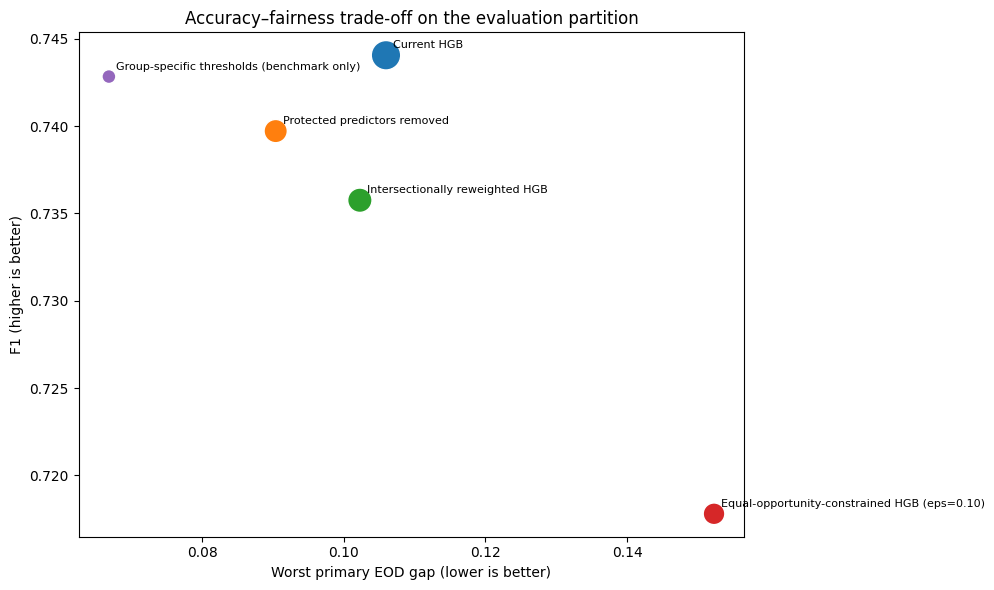

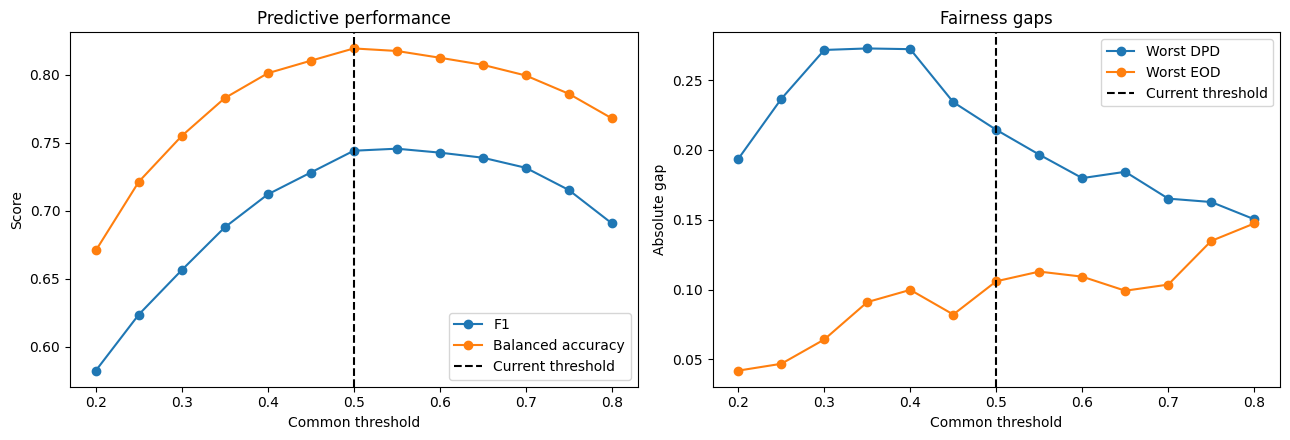

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))
plot_data = evaluation_comparison.copy()
sns.scatterplot(
    data=plot_data, x="worst_primary_eod", y="f1",
    size="worst_primary_dpd", sizes=(100, 450), hue="model", ax=ax,
)
for _, row in plot_data.iterrows():
    ax.annotate(row["model"], (row["worst_primary_eod"], row["f1"]),
                xytext=(5, 5), textcoords="offset points", fontsize=8)
ax.set_xlabel("Worst primary EOD gap (lower is better)")
ax.set_ylabel("F1 (higher is better)")
ax.set_title("Accuracy–fairness trade-off on the evaluation partition")
ax.legend([], [], frameon=False)
plt.tight_layout()
plt.show()

threshold_rows = []
for threshold in np.linspace(0.20, 0.80, 13):
    pred = (baseline_prob >= threshold).astype(int)
    metrics = predictive_metrics("Current HGB", y_eval, pred, baseline_prob)
    groups = group_fairness_table(y_eval, pred, audit_eval, primary_attributes, "Current HGB")
    gaps = fairness_gap_table(groups)
    threshold_rows.append({
        "threshold": threshold, "f1": metrics["f1"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "worst_dpd": gaps["dpd"].max(), "worst_eod": gaps["eod"].max(),
    })
threshold_tradeoff = pd.DataFrame(threshold_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
axes[0].plot(threshold_tradeoff["threshold"], threshold_tradeoff["f1"], marker="o", label="F1")
axes[0].plot(threshold_tradeoff["threshold"], threshold_tradeoff["balanced_accuracy"], marker="o", label="Balanced accuracy")
axes[0].axvline(0.50, color="black", linestyle="--", label="Current threshold")
axes[0].set(title="Predictive performance", xlabel="Common threshold", ylabel="Score")
axes[0].legend()
axes[1].plot(threshold_tradeoff["threshold"], threshold_tradeoff["worst_dpd"], marker="o", label="Worst DPD")
axes[1].plot(threshold_tradeoff["threshold"], threshold_tradeoff["worst_eod"], marker="o", label="Worst EOD")
axes[1].axvline(0.50, color="black", linestyle="--", label="Current threshold")
axes[1].set(title="Fairness gaps", xlabel="Common threshold", ylabel="Absolute gap")
axes[1].legend()
plt.tight_layout()
plt.show()

### What the trade-off charts show

Protected-feature removal sits close to the original HGB in predictive performance while improving both worst DPD and worst EOD. The fairness-constrained model sacrifices too much recall and F1. The group-specific threshold benchmark looks strongest numerically but is intentionally excluded from selection because it uses group-aware decision rules.

## 12. Final check on the held-out test partition

The model choice and common threshold are now frozen. The held-out test data is used only for this final check.

The important question is not only whether the selected approach looked better on evaluation data, but whether its fairness measurements remain stable on a separate group of students.

In [18]:
X_development = pd.concat([X_train, X_eval], axis=0)
y_development = pd.concat([y_train, y_eval], axis=0)
audit_development = pd.concat([audit_train, audit_eval], axis=0, ignore_index=True)
intersection_development = pd.concat([intersection_train, intersection_eval], axis=0, ignore_index=True)

if selected_model_name == "Current HGB":
    final_model = make_hgb()
    final_model.fit(X_development, y_development, model__sample_weight=withdrawal_weights(y_development))
    final_probability = final_model.predict_proba(X_test)[:, 1]
    final_prediction = (final_probability >= selected_threshold).astype(int)
elif selected_model_name == "Protected predictors removed":
    final_model = make_hgb(unaware_numeric, unaware_categorical)
    final_model.fit(
        X_development[unaware_features], y_development,
        model__sample_weight=withdrawal_weights(y_development),
    )
    final_probability = final_model.predict_proba(X_test[unaware_features])[:, 1]
    final_prediction = (final_probability >= selected_threshold).astype(int)
elif selected_model_name == "Intersectionally reweighted HGB":
    final_model = make_hgb()
    final_model.fit(
        X_development, y_development,
        model__sample_weight=intersectional_weights(y_development, intersection_development),
    )
    final_probability = final_model.predict_proba(X_test)[:, 1]
    final_prediction = (final_probability >= selected_threshold).astype(int)
else:
    final_model = ExponentiatedGradient(
        estimator=make_hgb(unaware_numeric, unaware_categorical),
        constraints=TruePositiveRateParity(difference_bound=selected_epsilon),
        objective=ErrorRate(), eps=0.02, max_iter=12,
        sample_weight_name="model__sample_weight",
    )
    final_model.fit(
        X_development[unaware_features], y_development,
        sensitive_features=intersection_development,
    )
    final_probability = None
    final_prediction = final_model.predict(
        X_test[unaware_features], random_state=42
    ).astype(int)

test_metrics = pd.DataFrame([
    predictive_metrics(selected_model_name, y_test, final_prediction, final_probability)
])
test_group_table = group_fairness_table(
    y_test.reset_index(drop=True), final_prediction, audit_test,
    all_audit_attributes, selected_model_name,
)
test_gaps = fairness_gap_table(test_group_table)
test_worst_dpd, test_worst_eod = worst_primary_gaps(test_gaps, selected_model_name)

display(test_metrics.style.format({
    "accuracy": "{:.3f}", "balanced_accuracy": "{:.3f}",
    "roc_auc": lambda x: "—" if pd.isna(x) else f"{x:.3f}",
    "pr_auc": lambda x: "—" if pd.isna(x) else f"{x:.3f}",
    "precision": "{:.3f}", "recall": "{:.3f}", "f1": "{:.3f}",
}))
display(test_gaps[test_gaps["attribute"].isin(primary_attributes)].style.format({
    "dpd": "{:.3f}", "dp_ratio": "{:.3f}", "eod": "{:.3f}",
}))

,model,accuracy,balanced_accuracy,precision,recall,f1,fp,fn,roc_auc,pr_auc
0,Protected predictors removed,0.817,0.803,0.672,0.767,0.717,552,343,0.874,0.795


,model,attribute,eligible_groups,dpd,dp_ratio,eod,lowest_selection_group,highest_selection_group,lowest_recall_group,highest_recall_group
0,Protected predictors removed,gender,2,0.044,0.878,0.021,F,M,F,M
1,Protected predictors removed,disability,2,0.073,0.822,0.006,N,Y,N,Y
2,Protected predictors removed,imd_band,10,0.169,0.610,0.111,80-90%,0-10%,80-90%,60-70%
3,Protected predictors removed,gender_x_disability,4,0.179,0.640,0.159,F | disability=N,M | disability=Y,F | disability=Y,M | disability=Y
4,Protected predictors removed,disability_x_deprivation,4,0.167,0.648,0.061,N | Other known IMD,Y | Lowest 30% IMD,Y | Other known IMD,Y | Lowest 30% IMD


### What happened on the held-out test

- The selected model achieved F1 `0.717` and balanced accuracy `0.803`.
- Test DPD was `0.179`, almost identical to its evaluation value of `0.180`.
- Test EOD was `0.159`, substantially higher than the evaluation value of `0.090`.

The DPD result remained stable, but the EOD improvement did not remain equally strong on new students. The original HGB's fairness was not calculated on this same final test partition, so this notebook cannot claim that protected-feature removal improved test EOD relative to the original model.

The honest conclusion is that protected-feature removal was the best evaluation-stage mitigation, but equal-opportunity performance still requires monitoring and further validation.

## 13. Comparison with the earlier XGBoost fairness section

The earlier baseline notebook contained a useful fairness experiment, but it audited XGBoost variants. Its recorded evaluation results showed that removing protected predictors reduced the gender × disability recall gap from approximately `0.107` to `0.058` without reducing F1, while the Fairlearn-constrained XGBoost result was mixed.

This notebook answers the mentor's question more directly because it audits the **weighted HistGradientBoosting model used for our headline baseline**. Values should not be compared as if they came from different datasets: both experiments use the same OULAD target and checkpoint, but the model families and mitigation procedures differ.

## 14. Final conclusions

The following conclusion separates evaluation evidence from the held-out test result. That distinction matters because an improvement observed during model selection may not remain equally strong on new students.

In [19]:
baseline_eval = evaluation_comparison.set_index("model").loc["Current HGB"]
selected_eval = evaluation_comparison.set_index("model").loc[selected_model_name]
eod_reduction = baseline_eval["worst_primary_eod"] - selected_eval["worst_primary_eod"]
dpd_reduction = baseline_eval["worst_primary_dpd"] - selected_eval["worst_primary_dpd"]
f1_change = selected_eval["f1"] - baseline_eval["f1"]

summary = f"""
### What we found

1. **The original model flagged some groups more often than others.** Its worst evaluation DPD was **{baseline_eval['worst_primary_dpd']:.3f}**, or **{baseline_eval['worst_primary_dpd'] * 100:.1f} percentage points**. The largest differences involved disability, deprivation and their intersections—not gender alone. DPD does not account for actual withdrawal rates, so this is a reason to investigate rather than proof of unfairness.

2. **Actual withdrawals were not detected equally across every group.** The original model's worst evaluation EOD was **{baseline_eval['worst_primary_eod']:.3f}**, or **{baseline_eval['worst_primary_eod'] * 100:.1f} percentage points**.

3. **Removing protected predictors was the best practical group-blind mitigation.** It reduced evaluation DPD by **{dpd_reduction:.3f}** and EOD by **{eod_reduction:.3f}**, while F1 changed by only **{f1_change:+.3f}**.

4. **The explicitly fairness-constrained model was rejected.** It reduced flagging-rate differences but worsened EOD, recall, F1 and the number of missed withdrawals.

5. **Group-specific thresholds produced the best numerical fairness result but were not selected.** They require protected group information and apply different decision rules at prediction time.

6. **The held-out test result was mixed.** The selected model's DPD was **{test_worst_dpd:.3f}**, close to evaluation, but its EOD was **{test_worst_eod:.3f}**, considerably higher. The EOD improvement therefore did not remain equally strong on new students.

### Recommendation

Retain **{selected_model_name}** as the best candidate from this comparison because it improved evaluation fairness with almost no predictive loss. Do **not** describe the model as conclusively fair. Continue monitoring group recall and false-alert rates, particularly for disability × deprivation and gender × disability groups.

The original model's fairness was not calculated on the same final test partition, so we cannot claim a direct test-set fairness improvement over the original model.
"""
display(Markdown(summary))


### What we found

1. **The original model flagged some groups more often than others.** Its worst evaluation DPD was **0.214**, or **21.4 percentage points**. The largest differences involved disability, deprivation and their intersections—not gender alone. DPD does not account for actual withdrawal rates, so this is a reason to investigate rather than proof of unfairness.

2. **Actual withdrawals were not detected equally across every group.** The original model's worst evaluation EOD was **0.106**, or **10.6 percentage points**.

3. **Removing protected predictors was the best practical group-blind mitigation.** It reduced evaluation DPD by **0.034** and EOD by **0.016**, while F1 changed by only **-0.004**.

4. **The explicitly fairness-constrained model was rejected.** It reduced flagging-rate differences but worsened EOD, recall, F1 and the number of missed withdrawals.

5. **Group-specific thresholds produced the best numerical fairness result but were not selected.** They require protected group information and apply different decision rules at prediction time.

6. **The held-out test result was mixed.** The selected model's DPD was **0.179**, close to evaluation, but its EOD was **0.159**, considerably higher. The EOD improvement therefore did not remain equally strong on new students.

### Recommendation

Retain **Protected predictors removed** as the best candidate from this comparison because it improved evaluation fairness with almost no predictive loss. Do **not** describe the model as conclusively fair. Continue monitoring group recall and false-alert rates, particularly for disability × deprivation and gender × disability groups.

The original model's fairness was not calculated on the same final test partition, so we cannot claim a direct test-set fairness improvement over the original model.
